# Peloton-Aware Breakaway Model Demo

This notebook demonstrates the main workflow of the project:

- choose a terrain profile
- compare passive and strategically-aware peloton settings
- evaluate climber, sprinter, and time-trialist archetypes
- compute best breakaway strategies
- generate figures for the repository and website

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.rider_models import get_rider
from src.grid_search import GridSearchConfig, run_grid_search
from src.backward_method import LegacyScaling, PelotonParameters, peloton_time_nd
from src.strategic_peloton import passive_peloton, strategic_peloton
from src.plotting import (
    plot_finishing_time_vs_breakaway,
    plot_best_breakaway_points_on_track,
)

In [ ]:
track_name = "mountainous"   # "hill", "steep_hill", "double_hill"
rider_names = ["climber", "sprinter", "time_trialist"]

scaling = LegacyScaling()

passive = passive_peloton()
strategic = strategic_peloton(
    terrain_multiplier=1.1,
    slope_threshold=0.004,
    surge_start=0.8,
)

config = GridSearchConfig(
    n_powers=20,
    power_factor_min=1.275,
    power_factor_max=2.2,
    min_breakaway_location=0.4,
)

figures_dir = PROJECT_ROOT / "figures"
figures_dir.mkdir(exist_ok=True)

In [3]:
results_by_mode = {
    "passive": {},
    "strategic": {},
}

best_points_by_mode = {
    "passive": {},
    "strategic": {},
}

summary_rows = []

for rider_name in rider_names:
    rider = get_rider(rider_name)

    sweep_passive = run_grid_search(
        rider=rider,
        track_name=track_name,
        config=config,
        peloton=passive,
        scaling=scaling,
    )

    sweep_strategic = run_grid_search(
        rider=rider,
        track_name=track_name,
        config=config,
        peloton=strategic,
        scaling=scaling,
    )

    valid_passive = sweep_passive.feasible & np.isfinite(sweep_passive.total_time_minutes)
    valid_strategic = sweep_strategic.feasible & np.isfinite(sweep_strategic.total_time_minutes)

    results_by_mode["passive"][rider_name] = {
        "x_break": sweep_passive.x_break,
        "T_break": sweep_passive.total_time_minutes,
    }
    results_by_mode["strategic"][rider_name] = {
        "x_break": sweep_strategic.x_break,
        "T_break": sweep_strategic.total_time_minutes,
    }

    idx_passive = np.where(valid_passive)[0][np.argmin(sweep_passive.total_time_minutes[valid_passive])]
    idx_strategic = np.where(valid_strategic)[0][np.argmin(sweep_strategic.total_time_minutes[valid_strategic])]

    best_points_by_mode["passive"][rider_name] = {
        "x_break": sweep_passive.x_break[idx_passive],
        "power_wkg": sweep_passive.breakaway_power_wkg[idx_passive],
        "power_watts": sweep_passive.breakaway_power_watts[idx_passive],
        "time": sweep_passive.total_time_minutes[idx_passive],
    }
    best_points_by_mode["strategic"][rider_name] = {
        "x_break": sweep_strategic.x_break[idx_strategic],
        "power_wkg": sweep_strategic.breakaway_power_wkg[idx_strategic],
        "power_watts": sweep_strategic.breakaway_power_watts[idx_strategic],
        "time": sweep_strategic.total_time_minutes[idx_strategic],
    }

    summary_rows.append({
        "rider": rider_name,
        "peloton": "passive",
        "breakaway_location": sweep_passive.x_break[idx_passive],
        "breakaway_power_wkg": sweep_passive.breakaway_power_wkg[idx_passive],
        "breakaway_power_watts": sweep_passive.breakaway_power_watts[idx_passive],
        "total_time_minutes": sweep_passive.total_time_minutes[idx_passive],
    })
    summary_rows.append({
        "rider": rider_name,
        "peloton": "strategic",
        "breakaway_location": sweep_strategic.x_break[idx_strategic],
        "breakaway_power_wkg": sweep_strategic.breakaway_power_wkg[idx_strategic],
        "breakaway_power_watts": sweep_strategic.breakaway_power_watts[idx_strategic],
        "total_time_minutes": sweep_strategic.total_time_minutes[idx_strategic],
    })

In [4]:
summary_df = pd.DataFrame(summary_rows)
summary_df["breakaway_location"] = summary_df["breakaway_location"].round(3)
summary_df["breakaway_power_wkg"] = summary_df["breakaway_power_wkg"].round(2)
summary_df["breakaway_power_watts"] = summary_df["breakaway_power_watts"].round(1)
summary_df["total_time_minutes"] = summary_df["total_time_minutes"].round(2)
summary_df

,rider,peloton,breakaway_location,breakaway_power_wkg,breakaway_power_watts,total_time_minutes
0,climber,passive,0.452,6.12,397.9,163.83
1,climber,strategic,0.452,6.12,397.9,159.38
2,sprinter,passive,0.695,4.76,357.0,169.16
3,sprinter,strategic,0.890,8.21,616.0,161.62
4,time_trialist,passive,0.443,5.10,357.0,165.39
5,time_trialist,strategic,0.631,5.49,384.3,160.80


In [5]:
peloton_finish_times = {
    "passive": peloton_time_nd(1.0, track_name, scaling, passive) * scaling.time_scale / 60.0,
    "strategic": peloton_time_nd(1.0, track_name, scaling, strategic) * scaling.time_scale / 60.0,
}
peloton_finish_times

{'passive': np.float64(172.81448478837692),
 'strategic': np.float64(163.42613728170858)}

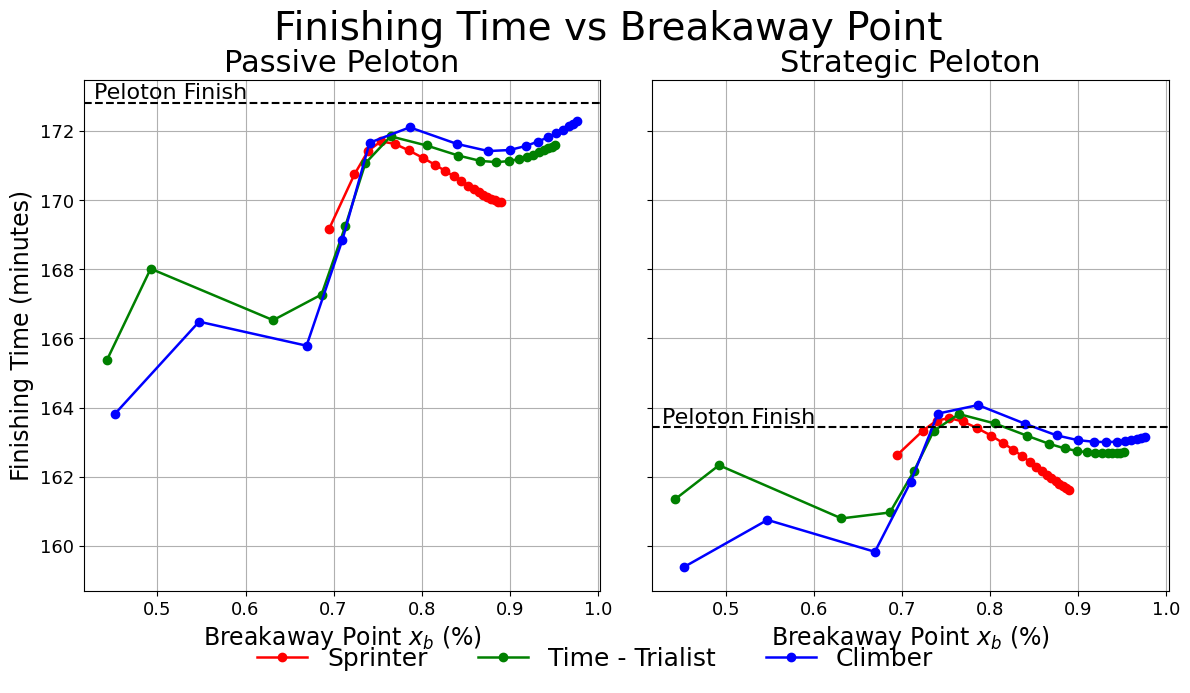

In [6]:
fig1, axs1 = plot_finishing_time_vs_breakaway(
    results_by_mode=results_by_mode,
    peloton_finish_times=peloton_finish_times,
    title="Finishing Time vs Breakaway Point",
)
plt.show()

In [7]:
save_path_1 = figures_dir / f"{track_name}_finishing_time_vs_breakaway.png"
fig1.savefig(save_path_1, dpi=220, bbox_inches="tight")
print(save_path_1)

/Users/chamu/peloton-aware-breakaway-model/figures/mountainous_finishing_time_vs_breakaway.png


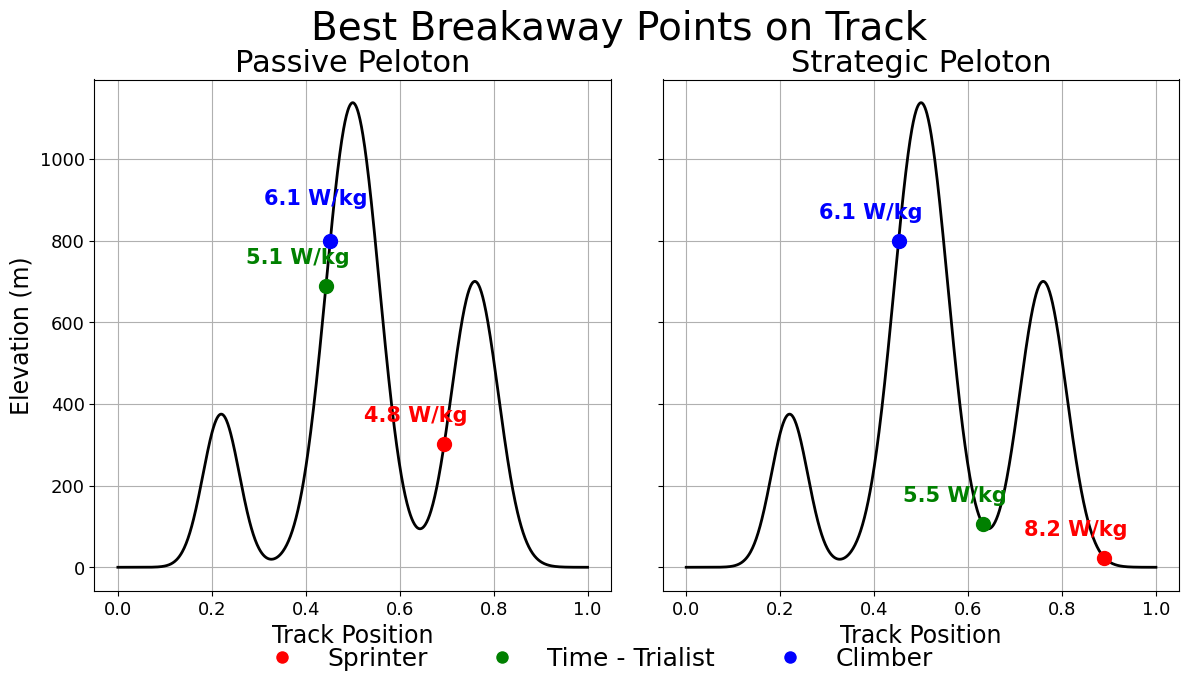

In [8]:
x_plot = np.linspace(0.0, 1.0, 1000)

fig2, axs2 = plot_best_breakaway_points_on_track(
    track_name=track_name,
    x_grid=x_plot,
    best_points_by_mode=best_points_by_mode,
    length_scale=scaling.length_scale,
    title="Best Breakaway Points on Track",
)
plt.show()

In [9]:
save_path_2 = figures_dir / f"{track_name}_best_breakaway_points.png"
fig2.savefig(save_path_2, dpi=220, bbox_inches="tight")
print(save_path_2)

/Users/chamu/peloton-aware-breakaway-model/figures/mountainous_best_breakaway_points.png


In [10]:
print("Summary")
print("-------")
for _, row in summary_df.iterrows():
    print(
        f"{row['rider']:15s} | {row['peloton']:10s} | "
        f"x_b = {row['breakaway_location']:.3f} | "
        f"P = {row['breakaway_power_wkg']:.2f} W/kg "
        f"({row['breakaway_power_watts']:.1f} W) | "
        f"T = {row['total_time_minutes']:.2f} min"
    )

Summary
-------
climber         | passive    | x_b = 0.452 | P = 6.12 W/kg (397.9 W) | T = 163.83 min
climber         | strategic  | x_b = 0.452 | P = 6.12 W/kg (397.9 W) | T = 159.38 min
sprinter        | passive    | x_b = 0.695 | P = 4.76 W/kg (357.0 W) | T = 169.16 min
sprinter        | strategic  | x_b = 0.890 | P = 8.21 W/kg (616.0 W) | T = 161.62 min
time_trialist   | passive    | x_b = 0.443 | P = 5.10 W/kg (357.0 W) | T = 165.39 min
time_trialist   | strategic  | x_b = 0.631 | P = 5.49 W/kg (384.3 W) | T = 160.80 min
